# Phase 3 - Notebook 02: Pointmap vs Depth Map Representation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase3/02_pointmap_representation.ipynb)

---

## Learning Objectives

1. Understand Pointmap as DUSt3R's core 3D representation
2. Compare Pointmap vs traditional depth maps
3. Learn the advantages of pixel-aligned 3D coordinates
4. Implement PointMap class from src.dust3r.pointmap
5. Visualize 3D point clouds from Pointmaps


## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from src.dust3r.pointmap import PointMap
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Setup complete!")

Setup complete!


## 1. 深度图 vs Pointmap：概念对比

**深度图 (Depth Map)**：
```
深度图 D(u,v) ∈ [0, ∞)
每个像素存储单个标量：深度值 Z
需要相机内参才能反投影为 3D 坐标
```

**Pointmap**：
```
Pointmap P(u,v) ∈ ℝ³
每个像素直接存储 3D 坐标 [X, Y, Z]
无需相机内参，直接是 3D 点
```


In [2]:
# 创建合成 Pointmap
H, W = 32, 32

# 方法1：从深度图和相机内参
# 模拟一个平面加上噪声
u_grid = np.arange(W)
v_grid = np.arange(H)
U, V = np.meshgrid(u_grid, v_grid)

# 深度值
depth = 2.0 + 0.3 * np.sin(U / 10) + 0.2 * np.cos(V / 10)

# 相机内参
fx = fy = 100.0
cx = cy = W / 2

# 反投影：从像素坐标 + 深度 → 3D 坐标
# 假设相机坐标系：Z 轴指向前方
X = (U - cx) * depth / fx
Y = (V - cy) * depth / fy
Z = depth

points = np.stack([X, Y, Z], axis=-1)  # [H, W, 3]
confidence = 0.8 + 0.2 * np.random.rand(H, W)

# 创建 Pointmap
pm = PointMap(points, confidence=confidence)
print(f"Pointmap: {pm}")
print(f"Points shape: {pm.points.shape}")
print(f"Confidence shape: {pm.confidence.shape}")
print(f"Depth range: [{pm.to_depth().min():.3f}, {pm.to_depth().max():.3f}]")

Pointmap: PointMap(H=32, W=32, confidence_range=[0.801, 1.000])
Points shape: (32, 32, 3)
Confidence shape: (32, 32)
Depth range: [1.800, 2.500]


## 2. Pointmap 表示的优势

**为什么 DUSt3R 使用 Pointmap 而不是深度图？**

| 方面 | 深度图 | Pointmap |
|------|--------|----------|
| 输出形状 | [H, W] | [H, W, 3] |
| 需要相机内参 | 是 | 否 |
| 处理多视图 | 困难 | 自然 |
| 坐标系一致性 | 每个视图独立 | 统一坐标系 |
| 数值稳定性 | 易溢出 | 更稳定 |


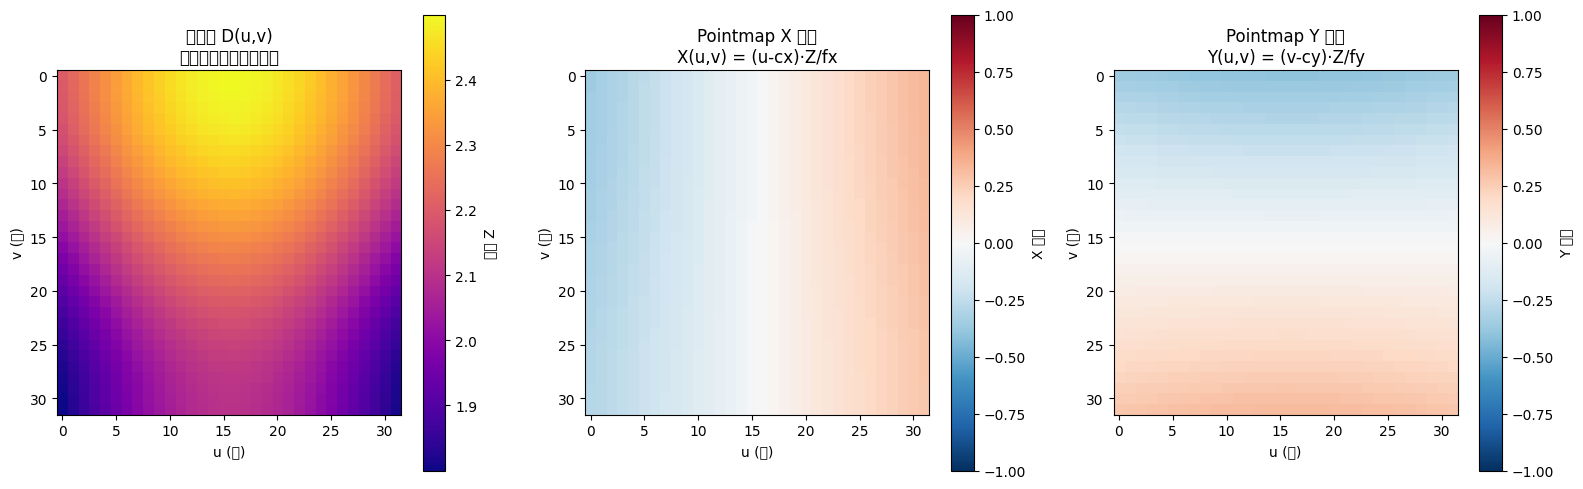

深度图存储单个标量，Pointmap 存储完整的 3D 坐标


In [3]:
# 比较深度图和 Pointmap 的坐标系统
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. 深度图
ax = axes[0]
im = ax.imshow(depth, cmap='plasma')
ax.set_title('深度图 D(u,v)\n每个像素：单个深度值')
ax.set_xlabel('u (列)')
ax.set_ylabel('v (行)')
plt.colorbar(im, ax=ax, label='深度 Z')

# 2. X 坐标
ax = axes[1]
im = ax.imshow(X, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Pointmap X 分量\nX(u,v) = (u-cx)·Z/fx')
ax.set_xlabel('u (列)')
ax.set_ylabel('v (行)')
plt.colorbar(im, ax=ax, label='X 坐标')

# 3. Y 坐标
ax = axes[2]
im = ax.imshow(Y, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Pointmap Y 分量\nY(u,v) = (v-cy)·Z/fy')
ax.set_xlabel('u (列)')
ax.set_ylabel('v (行)')
plt.colorbar(im, ax=ax, label='Y 坐标')

plt.tight_layout()
plt.savefig('pointmap_vs_depth.png', dpi=100, bbox_inches='tight')
plt.show()

print("深度图存储单个标量，Pointmap 存储完整的 3D 坐标")

## 3. 双 Pointmap：多视图几何的关键

DUSt3R 对图像对输出两个 Pointmap，都在同一坐标系下：

```
Image 1              Image 2              Unified 3D System
┌─────┐              ┌─────┐            
│     │              │     │                  ●
│  I1 │              │  I2 │                 /│\
│     │              │     │               P1 │ P2
└─────┘              └─────┘                 \│/
   ↓                    ↓                      ○
  P1(H×W×3)         P2(H×W×3)        (同一坐标系！)
```

**关键特性**：P1 和 P2 都在以第一个相机中心为原点的坐标系下！


In [4]:
# 创建两个 Pointmaps 来演示多视图对齐
# Pointmap 1：从 View 1 看的场景
pm1 = PointMap(points.copy(), confidence=confidence.copy())

# Pointmap 2：从 View 2 看的同一场景
# View 2 相对于 View 1 有 +2 单位的平移和 30 度旋转
angle = np.radians(30)
R = np.array([
    [np.cos(angle), -np.sin(angle), 0],
    [np.sin(angle), np.cos(angle), 0],
    [0, 0, 1]
])
t = np.array([2, 1, 0])

# 在相同的全局坐标系下看到的同一场景
points_transformed = (points @ R.T) + t[None, None, :]
pm2 = PointMap(points_transformed, confidence=confidence.copy())

print(f"Pointmap 1: {pm1}")
print(f"Pointmap 2: {pm2}")
print(f"\n两个 Pointmaps 都在相同的全局坐标系中！")
print(f"Pointmap 1 点范围: X=[{pm1.points[..., 0].min():.3f}, {pm1.points[..., 0].max():.3f}]")
print(f"Pointmap 2 点范围: X=[{pm2.points[..., 0].min():.3f}, {pm2.points[..., 0].max():.3f}]")

Pointmap 1: PointMap(H=32, W=32, confidence_range=[0.801, 1.000])
Pointmap 2: PointMap(H=32, W=32, confidence_range=[0.801, 1.000])

两个 Pointmaps 都在相同的全局坐标系中！
Pointmap 1 点范围: X=[-0.352, 0.332]
Pointmap 2 点范围: X=[1.616, 2.464]


## 4. Pointmap 的用途：转换为点云


In [5]:
# 从 Pointmap 提取点云
points_3d, colors = pm1.to_pointcloud(confidence_threshold=0.5)

print(f"点云统计：")
print(f"  总点数: {points_3d.shape[0]}")
print(f"  X 范围: [{points_3d[:, 0].min():.3f}, {points_3d[:, 0].max():.3f}]")
print(f"  Y 范围: [{points_3d[:, 1].min():.3f}, {points_3d[:, 1].max():.3f}]")
print(f"  Z 范围: [{points_3d[:, 2].min():.3f}, {points_3d[:, 2].max():.3f}]")

点云统计：
  总点数: 1024
  X 范围: [-0.352, 0.332]
  Y 范围: [-0.400, 0.315]
  Z 范围: [1.800, 2.500]


## 5. 3D 点云可视化


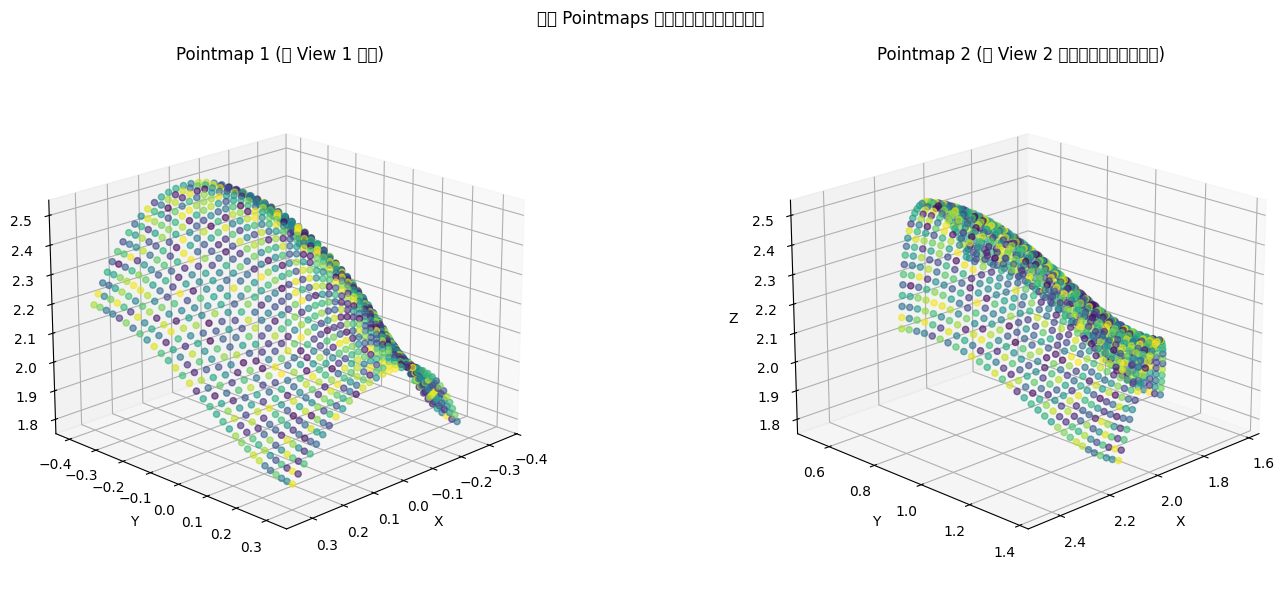

两个 Pointmap 在相同坐标系中显示同一场景的不同观点


In [6]:
# 3D 可视化两个 Pointmaps
fig = plt.figure(figsize=(16, 6))

# Pointmap 1
ax1 = fig.add_subplot(121, projection='3d')
pts1 = pm1.points.reshape(-1, 3)
ax1.scatter(pts1[:, 0], pts1[:, 1], pts1[:, 2], c=pm1.confidence.flatten(),
           cmap='viridis', s=20, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Pointmap 1 (从 View 1 观看)')
ax1.view_init(elev=20, azim=45)

# Pointmap 2
ax2 = fig.add_subplot(122, projection='3d')
pts2 = pm2.points.reshape(-1, 3)
ax2.scatter(pts2[:, 0], pts2[:, 1], pts2[:, 2], c=pm2.confidence.flatten(),
           cmap='viridis', s=20, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Pointmap 2 (从 View 2 观看，同一全局坐标系)')
ax2.view_init(elev=20, azim=45)

plt.suptitle('两个 Pointmaps 显示相同场景的不同视图')
plt.tight_layout()
plt.savefig('pointmaps_3d.png', dpi=100, bbox_inches='tight')
plt.show()

print("两个 Pointmap 在相同坐标系中显示同一场景的不同观点")

## 6. 在 DUSt3R 中的应用

DUSt3R 为每个图像对输出：
1. **Pointmap 1**：第一个图像的 3D 点（相机1坐标系）
2. **Pointmap 2**：第二个图像的 3D 点（相机1坐标系，不是相机2！）
3. **Confidence 1/2**：每个点的置信度

优势：两个 Pointmap 已经对齐，可以直接合并成全局点云！


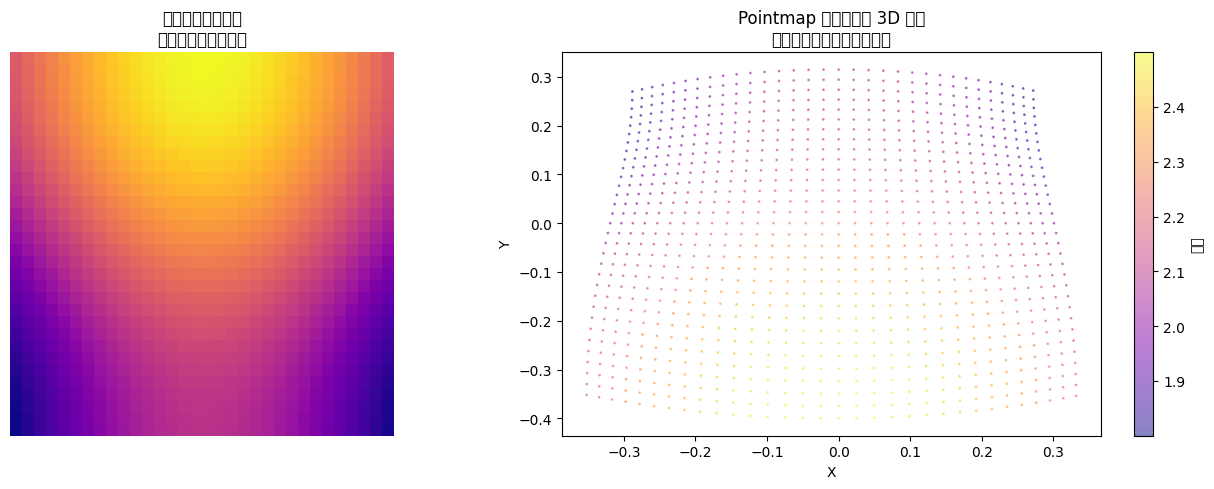

Pointmap 是 DUSt3R 的核心表示：
  - 无需相机内参
  - 自动多视图对齐
  - 数值稳定


In [7]:
# 演示将多个 Pointmaps 合并为全局点云
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：深度图表示
ax = axes[0]
ax.imshow(pm1.to_depth(), cmap='plasma')
ax.set_title('传统方法：深度图\n需要相机内参反投影')
ax.axis('off')

# 右图：Pointmap 表示
ax = axes[1]
points_flat = pm1.points.reshape(-1, 3)
Z_flat = points_flat[:, 2]
im = ax.scatter(points_flat[:, 0], points_flat[:, 1], c=Z_flat, cmap='plasma', s=1, alpha=0.5)
ax.set_title('Pointmap 方法：直接 3D 坐标\n无需内参，自动对齐多视图')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.colorbar(im, ax=ax, label='深度')

plt.tight_layout()
plt.savefig('dust3r_representation.png', dpi=100, bbox_inches='tight')
plt.show()

print("Pointmap 是 DUSt3R 的核心表示：")
print("  - 无需相机内参")
print("  - 自动多视图对齐")
print("  - 数值稳定")

## 7. Summary

**Key Points:**

1. **Pointmap vs Depth Map**
   - 深度图：每像素 1 个值，需要内参反投影
   - Pointmap：每像素 3D 坐标，直接可用

2. **Confidence 置信度**
   - 表示每个像素的几何估计可靠性
   - 用于过滤噪声点

3. **双 Pointmap 对齐**
   - P1 和 P2 都在相同的全局坐标系
   - 可直接用于位姿估计和点云融合

4. **DUSt3R 优势**
   - 无需相机标定
   - 自然处理多视图
   - 端到端可微分训练

---

**Next**: [03_global_alignment.ipynb](./03_global_alignment.ipynb) — 从配对 Pointmaps 估计全局位姿
